# Testing notebook

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import sys
import os

# Add the src directory to the Python path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(src_path)
print(f"Added to path: {src_path}")

# Import from your modules
from create_timeseries import construct_time_series
from vec_storage import TimeSeriesVectorStore
from data_input import load_data_csv, load_data_json, load_data_excel
from data_cleaning import clean_data

# Define process_dataset function since it's not in create_timeseries
def process_dataset(file_path, dataset_name=None):
    """
    Load, clean, and convert a dataset to time series format
    """
    # Load data based on file type
    if file_path.endswith('.csv'):
        df, _ = load_data_csv(file_path)
    elif file_path.endswith('.json'):
        df, _ = load_data_json(file_path)
    elif file_path.endswith(('.xlsx', '.xls')):
        df, _ = load_data_excel(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")
    
    # Clean data
    clean_df = clean_data(df, file_path, dataset_name)
    
    # Create time series
    ts = construct_time_series(clean_df)
    
    return ts, clean_df

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

Added to path: c:\Users\14379\Project\TsDev\src


In [10]:
# Define your datasets
datasets = [
    {"path": "../data/raw/avocado_full.csv", "name": "avocado_sales"},
    {"path": "../data/raw/donut_searches.json", "name": "donut_searches"},
]

# Process all datasets
time_series_data = {}
raw_data = {}

for dataset in datasets:
    print(f"Processing {dataset['name']}...")
    ts, df = process_dataset(dataset['path'], dataset['name'])
    time_series_data[dataset['name']] = ts
    raw_data[dataset['name']] = df
    print(f"  Time series length: {len(ts)}")

print("\nAll datasets processed successfully!")

Processing avocado_sales...
Data loaded successfully from ../data/raw/avocado_full.csv
1 - timestamp
2 - averageprice
3 - total volume
4 - 4046
5 - 4225
6 - 4770
7 - total bags
8 - small bags
9 - large bags
10 - xlarge bags
11 - type
12 - year
13 - region
Saved cleaned file to: ../data/cleaned\avocado_full_cleaned.csv
  Time series length: 1177
Processing donut_searches...
Data loaded successfully from ../data/raw/donut_searches.json
1 - timestamp
2 - search_count
Saved cleaned file to: ../data/cleaned\donut_searches_cleaned.csv
  Time series length: 92

All datasets processed successfully!


In [11]:
# First, let's recreate dataset_vectors with multiple windows from each time series
dataset_vectors = {}

for name, ts in time_series_data.items():
    # Instead of using the entire time series as one embedding,
    # let's create multiple embeddings using sliding windows
    window_size = 30
    stride = 10  # Smaller stride = more overlapping windows = more embeddings
    
    # Create sliding windows
    windows = []
    for i in range(0, len(ts) - window_size + 1, stride):
        window = ts.values[i:i+window_size]
        windows.append(window)
    
    dataset_vectors[name] = windows

print(f"Created {sum(len(windows) for windows in dataset_vectors.values())} windows total")
for name, windows in dataset_vectors.items():
    print(f"Dataset '{name}' has {len(windows)} windows")

# Now add these multiple windows to the vector store
window_size = 30
fft_components = 20

# Calculate the correct dimension
dimension = TimeSeriesVectorStore.calculate_embedding_dimension(window_size, fft_components)
print(f"Correct dimension: {dimension}")

# Create vector store with the correct dimension
vector_store = TimeSeriesVectorStore(dimension=dimension)

# Add all datasets to vector store
for source, windows in dataset_vectors.items():
    # Convert windows to numpy arrays
    time_series_list = [np.array(window) for window in windows]
    
    # Add to vector store
    vector_store.add_time_series(
        time_series_list, 
        window_size=window_size, 
        stride=1,  # Stride is 1 since we already created the windows
        fft_components=fft_components,
        source=source
    )

print(f"Vector store created with {vector_store.index.ntotal} embeddings")
print(f"Sources in vector store: {list(vector_store.sources)}")

# Let's check how many embeddings we have per source
for source in vector_store.sources:
    vectors, metadata, indices = vector_store.get_vectors_by_source(source)
    print(f"Source '{source}' has {len(vectors)} embeddings")

Created 122 windows total
Dataset 'avocado_sales' has 115 windows
Dataset 'donut_searches' has 7 windows
Correct dimension: 27
Added 115 embeddings from avocado_sales to index. Total: 115
Added 7 embeddings from donut_searches to index. Total: 122
Vector store created with 122 embeddings
Sources in vector store: ['donut_searches', 'avocado_sales']
Source 'donut_searches' has 7 embeddings
Source 'avocado_sales' has 115 embeddings


In [12]:
# Define dataset pairs to compare
source_pairs = [
    ("avocado_sales", "donut_searches"),
]

# Perform cross-dataset analysis
cross_similarities = {}
for source1, source2 in source_pairs:
    print(f"Comparing {source1} and {source2}...")
    similarities = vector_store.cross_dataset_similarity(source1, source2, top_k=5)
    cross_similarities[f"{source1}_{source2}"] = similarities

print("\nCross-dataset analysis completed!")

Comparing avocado_sales and donut_searches...

Cross-dataset analysis completed!


=== CROSS-DATASET SIMILARITY MATRIX ===
Similarity matrix shape: (122, 122)


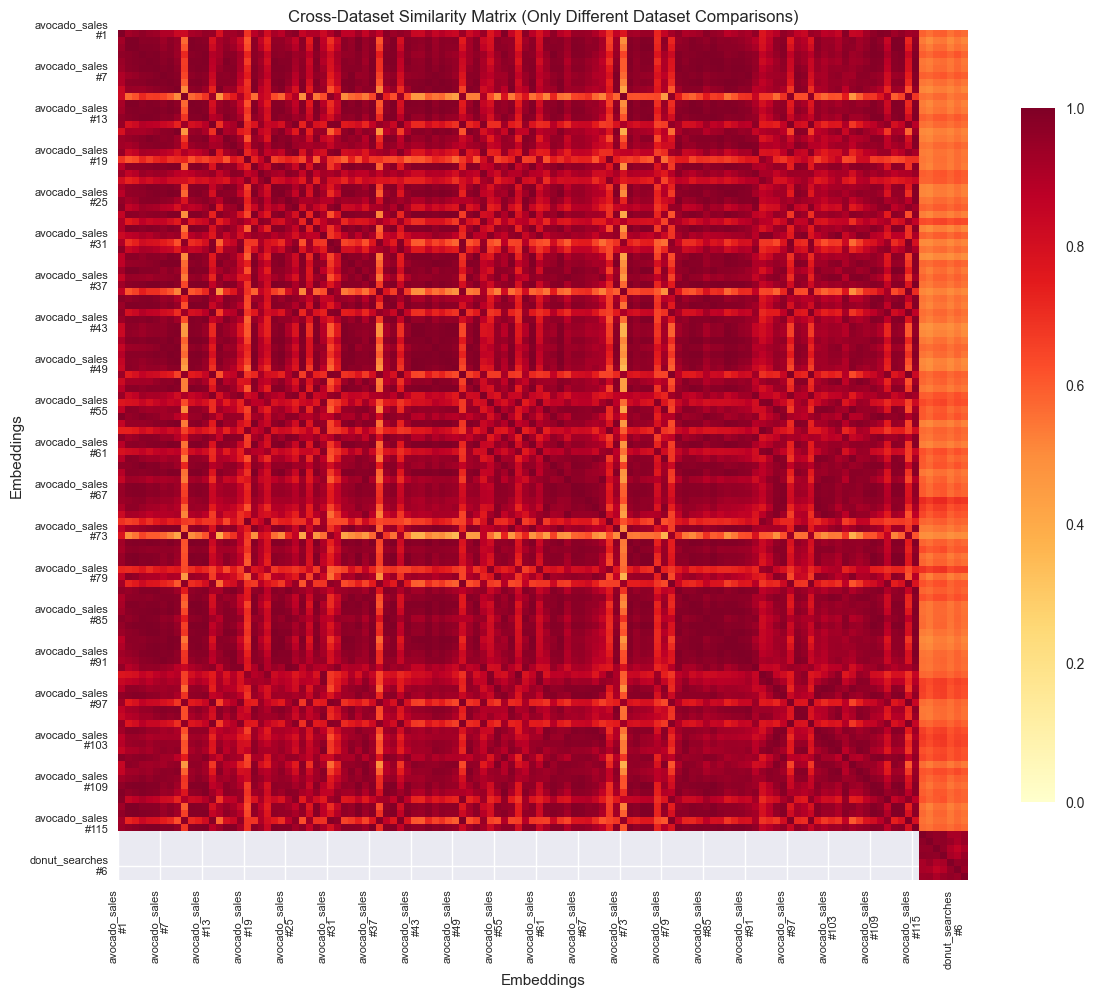

=== CROSS-DATASET SIMILARITY DISTRIBUTION ===


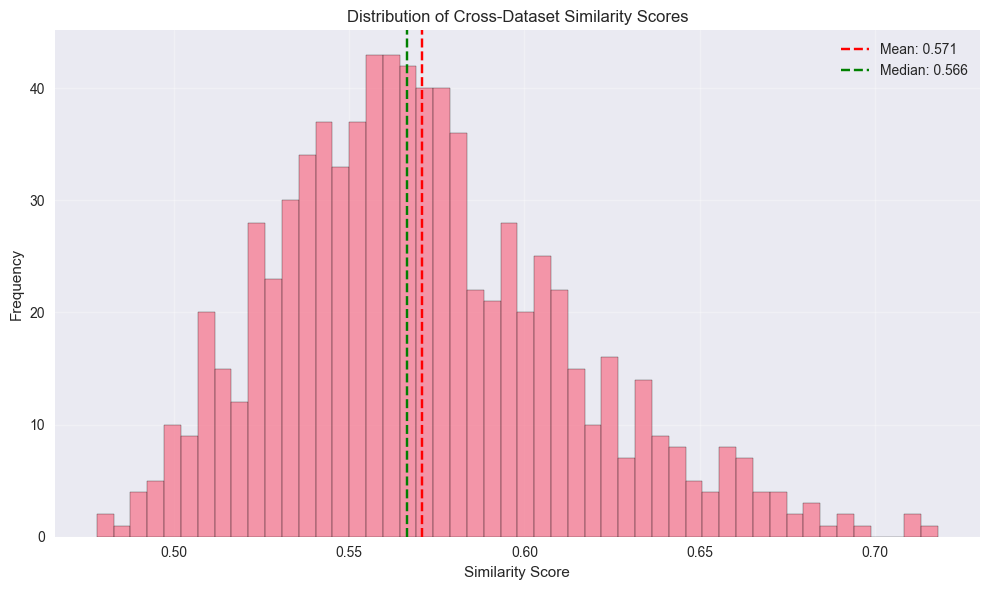

Number of embeddings: 122
Number of cross-dataset similarity comparisons: 805
Mean cross-dataset similarity: 0.571
Median cross-dataset similarity: 0.566
Min cross-dataset similarity: 0.478
Max cross-dataset similarity: 0.718

Sample of embeddings:
Index 0: avocado_sales
#1
Index 1: avocado_sales
#2
Index 2: avocado_sales
#3
Index 3: avocado_sales
#4
Index 4: avocado_sales
#5
Index 5: avocado_sales
#6
Index 6: avocado_sales
#7
Index 7: avocado_sales
#8
Index 8: avocado_sales
#9
Index 9: avocado_sales
#10


In [21]:
# Fixed Cross-Dataset Similarity Matrix
print("=== CROSS-DATASET SIMILARITY MATRIX ===")

# Get all vectors and their metadata
all_vectors = []
all_sources = []
all_indices = []

for i in range(vector_store.index.ntotal):
    try:
        vec = vector_store.index.reconstruct(i)
        all_vectors.append(vec)
        if i < len(vector_store.metadata):
            source = vector_store.metadata[i].get("source", "unknown")
            all_sources.append(source)
        else:
            all_sources.append("unknown")
        all_indices.append(i)
    except:
        continue

all_vectors = np.array(all_vectors)

# Compute the full similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(all_vectors)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

# Create a mask to only show cross-dataset comparisons
# We'll hide all same-dataset comparisons and the upper triangle
cross_dataset_mask = np.ones_like(similarity_matrix, dtype=bool)
for i in range(len(all_sources)):
    for j in range(len(all_sources)):
        # Hide same-dataset comparisons and upper triangle
        if all_sources[i] == all_sources[j] or i <= j:
            cross_dataset_mask[i, j] = False

# Create labels for each embedding
labels = []
source_counts = {}
for i, source in enumerate(all_sources):
    if source not in source_counts:
        source_counts[source] = 1
    else:
        source_counts[source] += 1
    labels.append(f"{source}\n#{source_counts[source]}")

# Create the cross-dataset similarity matrix heatmap
plt.figure(figsize=(12, 10))

# Sample labels if there are too many to display clearly
if len(labels) > 50:
    # Show every nth label to avoid overcrowding
    step = max(1, len(labels) // 20)
    sample_indices = range(0, len(labels), step)
    sample_labels = [labels[i] for i in sample_indices]
    
    heatmap = sns.heatmap(similarity_matrix, 
                          mask=cross_dataset_mask,
                          cmap="YlOrRd", 
                          vmin=0, vmax=1,
                          square=True,
                          xticklabels=sample_indices,
                          yticklabels=sample_indices,
                          cbar_kws={"shrink": 0.8})
    
    # Set the custom labels
    plt.xticks(sample_indices, sample_labels, rotation=90, fontsize=8)
    plt.yticks(sample_indices, sample_labels, rotation=0, fontsize=8)
else:
    # Show all labels if there aren't too many
    heatmap = sns.heatmap(similarity_matrix, 
                          mask=cross_dataset_mask,
                          cmap="YlOrRd", 
                          vmin=0, vmax=1,
                          square=True,
                          xticklabels=labels,
                          yticklabels=labels,
                          cbar_kws={"shrink": 0.8})
    
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

plt.xlabel("Embeddings")
plt.ylabel("Embeddings")
plt.title("Cross-Dataset Similarity Matrix (Only Different Dataset Comparisons)")
plt.tight_layout()
plt.show()

# Create a distribution of only cross-dataset similarities
print("=== CROSS-DATASET SIMILARITY DISTRIBUTION ===")

# Extract only cross-dataset similarities
cross_dataset_similarities = []
for i in range(similarity_matrix.shape[0]):
    for j in range(similarity_matrix.shape[1]):
        if all_sources[i] != all_sources[j] and i > j:  # Only cross-dataset and lower triangle
            cross_dataset_similarities.append(similarity_matrix[i, j])

# Create the distribution plot
plt.figure(figsize=(10, 6))
plt.hist(cross_dataset_similarities, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Cross-Dataset Similarity Scores")
plt.grid(True, alpha=0.3)

# Add vertical lines for mean and median
mean_sim = np.mean(cross_dataset_similarities)
median_sim = np.median(cross_dataset_similarities)
plt.axvline(mean_sim, color='red', linestyle='--', label=f'Mean: {mean_sim:.3f}')
plt.axvline(median_sim, color='green', linestyle='--', label=f'Median: {median_sim:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Number of embeddings: {len(all_vectors)}")
print(f"Number of cross-dataset similarity comparisons: {len(cross_dataset_similarities)}")
print(f"Mean cross-dataset similarity: {mean_sim:.3f}")
print(f"Median cross-dataset similarity: {median_sim:.3f}")
print(f"Min cross-dataset similarity: {np.min(cross_dataset_similarities):.3f}")
print(f"Max cross-dataset similarity: {np.max(cross_dataset_similarities):.3f}")

# Print a sample of the embeddings with their labels
print("\nSample of embeddings:")
for i in range(min(10, len(labels))):
    print(f"Index {i}: {labels[i]}")